In [4]:
# run first time
import sys
!{sys.executable} -m pip install "gymnasium[box2d]"==1.2.3
# !{sys.executable} -m pip install "gymnasium[box2d]" imageio statsmodels pyvirtualdisplay tensorflow matplotlib numpy "imageio[ffmpeg]"


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: /Users/wangrunyuan/.pyenv/versions/3.11.9/bin/python -m pip install --upgrade pip


In [1]:
import time
from collections import deque, namedtuple

import numpy as np
import PIL.Image
import tensorflow as tf
import utils
import matplotlib.pyplot as plt
from bidirection_lunar_lander import BidirectionalLunarLander

# from pyvirtualdisplay import Display
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.losses import MSE
from tensorflow.keras.optimizers import Adam

def fsm_inverted_controller(obs):
    """
    分阶段 naive inverted controller
    """

    y = obs[1]
    vy = obs[3]
    theta = obs[4]
    omega = obs[5]

    # 角度 wrap 到 [-pi, pi]
    theta_wrapped = np.arctan2(np.sin(theta), np.cos(theta))

    theta_abs = abs(theta_wrapped)

    # --------------------
    # Phase 0 / 1: 翻转阶段
    # --------------------
    if y > 1.3:
        return np.array([0, 0], dtype=np.float32)
    
    if theta_abs < 2.0:  # < ~150°
        # 目标：快速翻转，不管高度
        theta_ref = np.pi
        theta_err = np.arctan2(
            np.sin(theta - theta_ref),
            np.cos(theta - theta_ref)
        )

        # 姿态控制（侧推为主）
        # side = -2.5 * theta_err - 0.8 * omega
        side = -0.6

        # 主发动机：
        # 1) 正立时不要反推
        # 2) 给一个很小的正推，避免直接砸地
        main = 0.8

    # --------------------
    # Phase 2: 倒飞悬停
    # --------------------
    elif theta_abs > 2.0 and theta_abs < 3:
        side = 1
        main = -1
    else:
        theta_ref = np.pi
        y_ref = 1.5

        theta_err = np.arctan2(
            np.sin(theta - theta_ref),
            np.cos(theta - theta_ref)
        )

        # 姿态稳定
        # side = -2.0 * theta_err - 0.5 * omega
        side = 0

        # 高度控制（倒置时需要反推）
        #main = ( -0.7 - 0.6 * (y - y_ref) - 0.3 * vy)
        main = -0.5

    return np.array([
        np.clip(main, -1.0, 1.0),
        np.clip(side, -1.0, 1.0)
    ], dtype=np.float32)

env = BidirectionalLunarLander(continuous=True, render_mode="human")
obs, info = env.reset()

for step in range(500):
    action = fsm_inverted_controller(obs)
    # action = np.array([-1, 0], dtype=np.float32)
    # print(f"\r{action}")
    obs, reward, terminated, truncated, info = env.step(action)
    theta = obs[4]
    theta_w = np.arctan2(np.sin(theta), np.cos(theta))
    print(f"\raction: {action} theta: {theta_w}")

    if terminated or truncated:
        print(f"Episode ended: {step}")
        break

action: [0. 0.] theta: -0.01526052225381136
action: [0. 0.] theta: -0.02280634269118309
action: [0. 0.] theta: -0.030351169407367706
action: [0. 0.] theta: -0.037894777953624725
action: [0. 0.] theta: -0.04543719440698624
action: [0. 0.] theta: -0.05297838896512985
action: [0. 0.] theta: -0.060518376529216766
action: [0. 0.] theta: -0.06805717200040817
action: [0. 0.] theta: -0.07559476792812347
action: [0. 0.] theta: -0.08313117176294327
action: [0. 0.] theta: -0.09066639095544815
action: [0. 0.] theta: -0.09820044785737991
action: [0. 0.] theta: -0.10573331266641617
action: [0. 0.] theta: -0.11326500028371811
action: [0. 0.] theta: -0.12079551070928574
action: [0. 0.] theta: -0.12832488119602203
action: [0. 0.] theta: -0.13585308194160461
action: [0. 0.] theta: -0.14338015019893646
action: [0. 0.] theta: -0.1509060263633728
action: [0. 0.] theta: -0.1584307998418808
action: [0. 0.] theta: -0.16595439612865448
action: [0. 0.] theta: -0.17347684502601624
action: [0. 0.] theta: -0.18099

Episode ended: 0


2026-01-02 20:52:06.593 python[94838:356158709] error messaging the mach port for IMKCFRunLoopWakeUpReliable


In [4]:
def generate_inverted_hover_reference(
    T=300,          # 总轨迹长度
    dt=1/50,        # 环境时间步
    y0=1.5,         # 倒悬停高度
    amp=0.05,       # hover 震荡幅度
    freq=2.0        # hover 震荡频率
):
    """
    生成一个 inverted hover 参考轨迹：
    - 从正常 upright 慢慢翻转到倒置姿态
    - 在倒置阶段做小幅周期高度扰动

    返回：
        reference_states : (T, 8) ndarray
    """

    # t 步索引
    t_arr = np.arange(T)

    # 1) 姿态 angle(t)
    # sigmoid 风格的 smooth 翻转
    theta_ref = np.pi * 0.5 * (1 - np.cos(np.pi * t_arr / T))

    # 2) 高度 y_ref(t)
    # 小幅 sin 震荡让 hover 有一个 "可跟踪的流形"
    y_ref = y0 + amp * np.sin(2 * np.pi * freq * t_arr * dt)

    # 3) 速度与角速度（用差分估计）
    vy_ref = np.zeros_like(y_ref)
    omega_ref = np.zeros_like(theta_ref)

    # 终端差分边界处理
    for i in range(T - 1):
        vy_ref[i] = (y_ref[i + 1] - y_ref[i]) / dt
        omega_ref[i] = (theta_ref[i + 1] - theta_ref[i]) / dt

    # 最后一个点维持最后速度
    vy_ref[-1] = vy_ref[-2]
    omega_ref[-1] = omega_ref[-2]

    # 4) 组装 reference state
    # LunarLander 观测是 8 维：
    # [x, y, vx, vy, angle, angular_velocity, leg1_contact, leg2_contact]
    reference_states = np.zeros((T, 8), dtype=np.float32)

    for i in range(T):
        reference_states[i] = np.array([
            0.0,            # x 设为 0
            y_ref[i],
            0.0,            # vx=0
            vy_ref[i],
            theta_ref[i],   # angle（rad）
            omega_ref[i],   # angular_velocity（rad/s）
            0.0,            # leg1_contact=False
            0.0             # leg2_contact=False
        ], dtype=np.float32)

    return reference_states

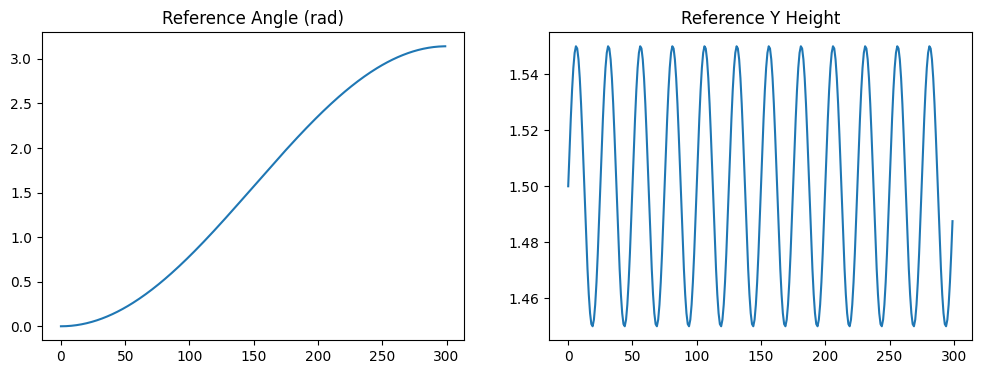

In [7]:
refs = generate_inverted_hover_reference(T=300)

angles = refs[:, 4]
heights = refs[:, 1]

plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(angles)
plt.title("Reference Angle (rad)")

plt.subplot(122)
plt.plot(heights)
plt.title("Reference Y Height")

plt.show()

In [8]:
class ReferenceTrackerWrapper(gym.Wrapper):
    def __init__(self, env, reference_traj):
        super().__init__(env)
        self.reference_traj = reference_traj
        self.t = 0
        self.T = len(reference_traj)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.t = 0
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        # 当前 reference state
        s_ref = self.reference_traj[min(self.t, self.T - 1)]
        info["s_ref"] = s_ref
        info["t"] = self.t

        self.t += 1
        return obs, reward, terminated, truncated, info

class TrackingRewardWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)

        # 权重（可以后续调）
        self.w_y = 5.0
        self.w_vy = 2.0
        self.w_theta = 10.0
        self.w_omega = 1.0
        self.w_action = 0.1

    def step(self, action):
        obs, _, terminated, truncated, info = self.env.step(action)
        s_ref = info["s_ref"]

        # obs: [x, y, vx, vy, angle, angular_velocity, leg1, leg2]
        y, vy = obs[1], obs[3]
        theta, omega = obs[4], obs[5]

        y_r, vy_r = s_ref[1], s_ref[3]
        theta_r, omega_r = s_ref[4], s_ref[5]

        # 角度误差
        dtheta = np.arctan2(
            np.sin(theta - theta_r),
            np.cos(theta - theta_r)
        )

        reward = -(
            self.w_y * (y - y_r) ** 2 +
            self.w_vy * (vy - vy_r) ** 2 +
            self.w_theta * dtheta ** 2 +
            self.w_omega * (omega - omega_r) ** 2 +
            self.w_action * np.sum(action ** 2)
        )

        return obs, reward, terminated, truncated, info

class ReferenceObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        low = np.concatenate([env.observation_space.low,
                              env.observation_space.low])
        high = np.concatenate([env.observation_space.high,
                               env.observation_space.high])
        self.observation_space = gym.spaces.Box(low, high, dtype=np.float32)

    def observation(self, obs):
        s_ref = self.env.unwrapped._last_info["s_ref"]
        return np.concatenate([obs, s_ref])

In [ ]:
def angle_error(theta, theta_ref):
    return np.arctan2(
        np.sin(theta - theta_ref),
        np.cos(theta - theta_ref)
    )

In [ ]:
#####################

In [5]:
# Set the random seed for TensorFlow
tf.random.set_seed(utils.SEED)

In [6]:
MEMORY_SIZE = 100_000     # size of memory buffer
GAMMA = 0.995             # discount factor
ALPHA = 1e-4              # learning rate  
NUM_STEPS_FOR_UPDATE = 4  # perform a learning update every C time steps
MAX_TIME_LIMIT = 500      # max time limit
X_RANGE_INIT = 0.5
Y_RANGE_INIT = 0.3
X_RANGE_END = 0.01
Y_RANGE_END = 0.01

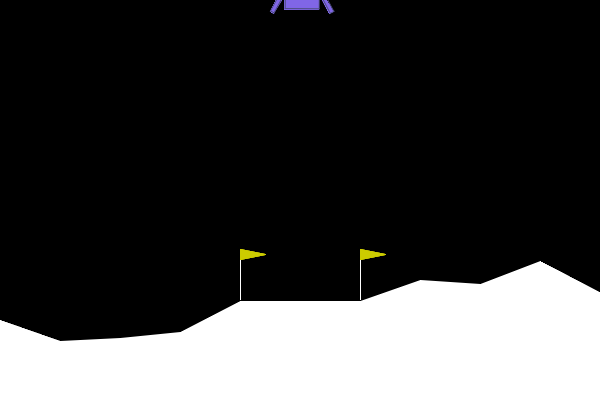

In [8]:
env.reset()
PIL.Image.fromarray(env.render())

In [9]:
# UNQ_C1
# GRADED CELL

state_size = env.observation_space.shape
num_actions = env.action_space.n

# Create the Q-Network
q_network = Sequential([
    Input(shape=state_size),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_actions, activation='linear')
    ])

# Create the target Q^-Network
target_q_network = Sequential([
    Input(shape=state_size),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_actions, activation='linear')
    ])

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=ALPHA,
    decay_steps=10000,
    decay_rate=0.96,
    staircase=True
)
optimizer = Adam(learning_rate=lr_schedule)

In [10]:
# Store experiences as named tuples
experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])

In [11]:
# UNQ_C2
# GRADED FUNCTION: calculate_loss

def compute_loss(experiences, gamma, q_network, target_q_network):
    """ 
    Calculates the loss.
    
    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
      q_network: (tf.keras.Sequential) Keras model for predicting the q_values
      target_q_network: (tf.keras.Sequential) Karas model for predicting the targets
          
    Returns:
      loss: (TensorFlow Tensor(shape=(0,), dtype=int32)) the Mean-Squared Error between
            the y targets and the Q(s,a) values.
    """
    
    # Unpack the mini-batch of experience tuples
    states, actions, rewards, next_states, done_vals = experiences
    
    # Compute max Q^(s,a)
    max_qsa = tf.reduce_max(target_q_network(next_states), axis=-1)
    
    # Set y = R if episode terminates, otherwise set y = R + γ max Q^(s,a).
    y_targets = rewards + (1.0 - done_vals) * gamma * max_qsa
    
    # Get the q_values
    q_values = q_network(states)
    q_values = tf.gather_nd(q_values, tf.stack([tf.range(q_values.shape[0]),
                                                tf.cast(actions, tf.int32)], axis=1))
        
    # Compute the loss
    loss = MSE(y_targets, q_values)
    
    return loss

In [12]:
@tf.function
def agent_learn(experiences, gamma):
    """
    Updates the weights of the Q networks.
    
    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
    
    """
    
    # Calculate the loss
    with tf.GradientTape() as tape:
        loss = compute_loss(experiences, gamma, q_network, target_q_network)

    # Get the gradients of the loss with respect to the weights.
    gradients = tape.gradient(loss, q_network.trainable_variables)
    
    # Update the weights of the q_network.
    optimizer.apply_gradients(zip(gradients, q_network.trainable_variables))

    # update the weights of target q_network
    utils.update_target_network(q_network, target_q_network)

In [13]:
start = time.time()

num_episodes = 4000
max_num_timesteps = 1000

total_point_history = []

num_p_av = 100    # number of total points to use for averaging
epsilon = 1.0     # initial ε value for ε-greedy policy

# Create a memory buffer D with capacity N
memory_buffer = deque(maxlen=MEMORY_SIZE)

# Set the target network weights equal to the Q-Network weights
target_q_network.set_weights(q_network.get_weights())

step = 5
range_step_x = (X_RANGE_INIT - X_RANGE_END) / step
range_step_y = (Y_RANGE_INIT - Y_RANGE_END) / step
for i in range(step+1):   
    curr_x_range = X_RANGE_INIT - range_step_x * i
    curr_y_range = Y_RANGE_INIT - range_step_y * i
    env.unwrapped.update_range(x_range = curr_x_range, y_range = curr_y_range) 
    total_point_history = []
    print(f"\rStep{i}, x range: {curr_x_range}, y range: {curr_y_range}")
    
    for i in range(num_episodes):
        
        # Reset the environment to the initial state and get the initial state
        state, _ = env.reset()
        total_points = 0
        
        for t in range(max_num_timesteps):
            
            # From the current state S choose an action A using an ε-greedy policy
            state_qn = np.expand_dims(state, axis=0)  # state needs to be the right shape for the q_network
            q_values = q_network(state_qn)
            action = utils.get_action(q_values, epsilon)
            
            # Take action A and receive reward R and the next state S'
            next_state, reward, done, _, _ = env.step(action)
            
            # Store experience tuple (S,A,R,S') in the memory buffer.
            # We store the done variable as well for convenience.
            memory_buffer.append(experience(state, action, reward, next_state, done))
            
            # Only update the network every NUM_STEPS_FOR_UPDATE time steps.
            update = utils.check_update_conditions(t, NUM_STEPS_FOR_UPDATE, memory_buffer)
            
            if update:
                # Sample random mini-batch of experience tuples (S,A,R,S') from D
                experiences = utils.get_experiences(memory_buffer)
                
                # Set the y targets, perform a gradient descent step,
                # and update the network weights.
                agent_learn(experiences, GAMMA)
            
            state = next_state.copy()
            total_points += reward
            
            if done:
                break
                
        total_point_history.append(total_points)
        av_latest_points = np.mean(total_point_history[-num_p_av:])
        
        # Update the ε value
        epsilon = utils.get_new_eps(epsilon)
    
        print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}", end="")
    
        if (i+1) % num_p_av == 0:
            print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}")
    
        # We will consider that the environment is solved if we get an
        # average of 200 points in the last 100 episodes.
        if av_latest_points >= 200.0:
            print(f"\n\nEnvironment solved in {i+1} episodes!")
            q_network.save('lunar_lander_model.h5')
            break
        
tot_time = time.time() - start

print(f"\nTotal Runtime: {tot_time:.2f} s ({(tot_time/60):.2f} min)")

Step0, x range: 0.5, y range: 0.3
Episode 100 | Total point average of the last 100 episodes: -238.39
Episode 200 | Total point average of the last 100 episodes: -100.14
Episode 300 | Total point average of the last 100 episodes: -65.042
Episode 400 | Total point average of the last 100 episodes: -72.64
Episode 500 | Total point average of the last 100 episodes: -75.54
Episode 600 | Total point average of the last 100 episodes: -55.22
Episode 700 | Total point average of the last 100 episodes: -27.01
Episode 800 | Total point average of the last 100 episodes: -36.28
Episode 900 | Total point average of the last 100 episodes: -25.83
Episode 1000 | Total point average of the last 100 episodes: -16.12
Episode 1100 | Total point average of the last 100 episodes: -37.63
Episode 1200 | Total point average of the last 100 episodes: -25.92
Episode 1300 | Total point average of the last 100 episodes: -19.10
Episode 1400 | Total point average of the last 100 episodes: -18.16
Episode 1500 | Total

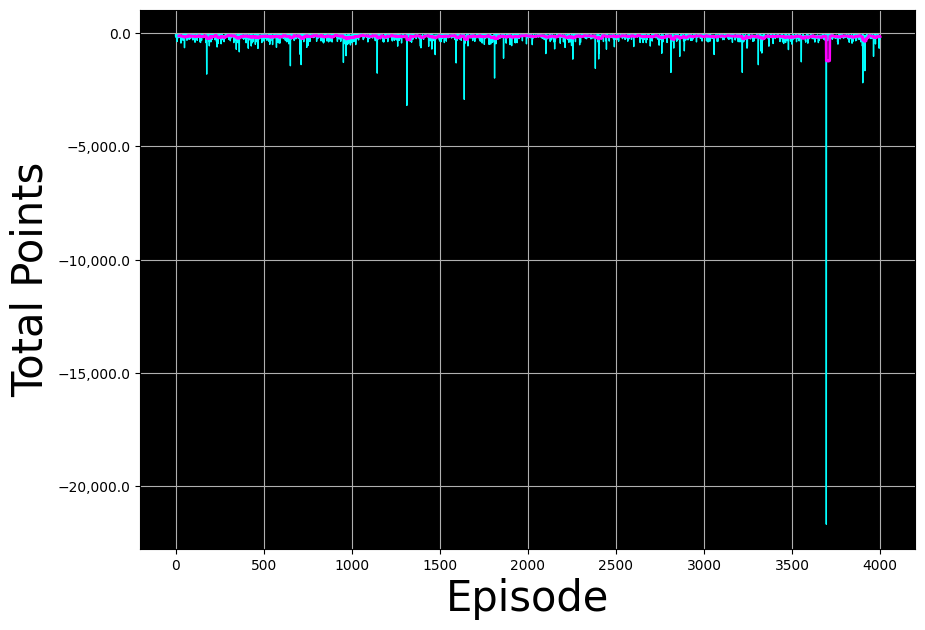

In [14]:
# Plot the point history
utils.plot_history(total_point_history)

In [15]:
# Suppress warnings from imageio
import logging
logging.getLogger().setLevel(logging.ERROR)

In [16]:
filename = "./videos/lunar_lander.mp4"

utils.create_video(filename, env, q_network)
utils.embed_mp4(filename)